سوال ۳ بخش آمار توصیفی از ما می‌خواهد آگهی‌های منتشرشده در ماه‌های مختلف را براق فروش و اجاره بررسی کنیم و ببینیم آیا آگهی‌های فروش و اجاره در زمان‌های مشخصی از سال افزایش چشمگیری داشته است یا خیر

برای این سوال ابتدا ستون تاریخ انتشار آگهی را به تاریخ شمسی تبدیل کرده‌ایم. سپس آگهی‌های املاک را بر مبنای فروش و اجاره و مسکونی و تجاری در چهار گروه دسته‌بندی و نمودار آن را رسم کردیم

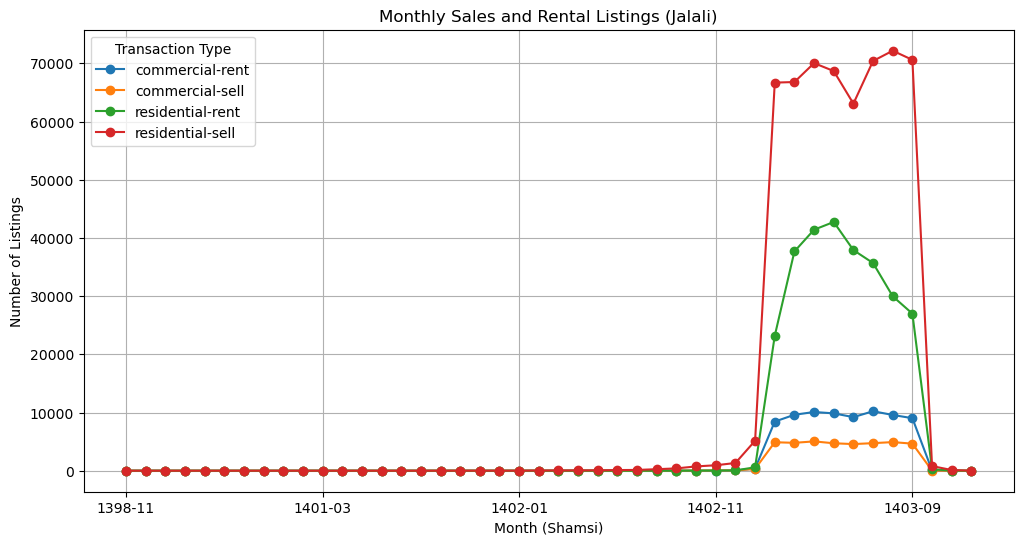

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import jdatetime


df = pd.read_csv("Divar.csv", low_memory=False)

#  تبدیل تاریخ به شمسی
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

df["created_at_month_shamsi"] = df["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

# گروه‌بندی
monthly_counts = (
    df[
        df["cat2_slug"].isin(
            [
                "residential-sell",
                "residential-rent",
                "commercial-rent",
                "commercial-sell",
            ]
        )
    ]
    .groupby(["created_at_month_shamsi", "cat2_slug"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

#print(monthly_counts)

#  رسم نمودار
monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Monthly Sales and Rental Listings (Jalali)")
plt.xlabel("Month (Shamsi)")
plt.ylabel("Number of Listings")
plt.grid(True)
plt.legend(title="Transaction Type")

plt.show()


یک بار هم آکهی‌های اجاره و فروش مسکونی و تجاری را با هم تجمیع کردیم و نمودار هر دو را رسم کردیم


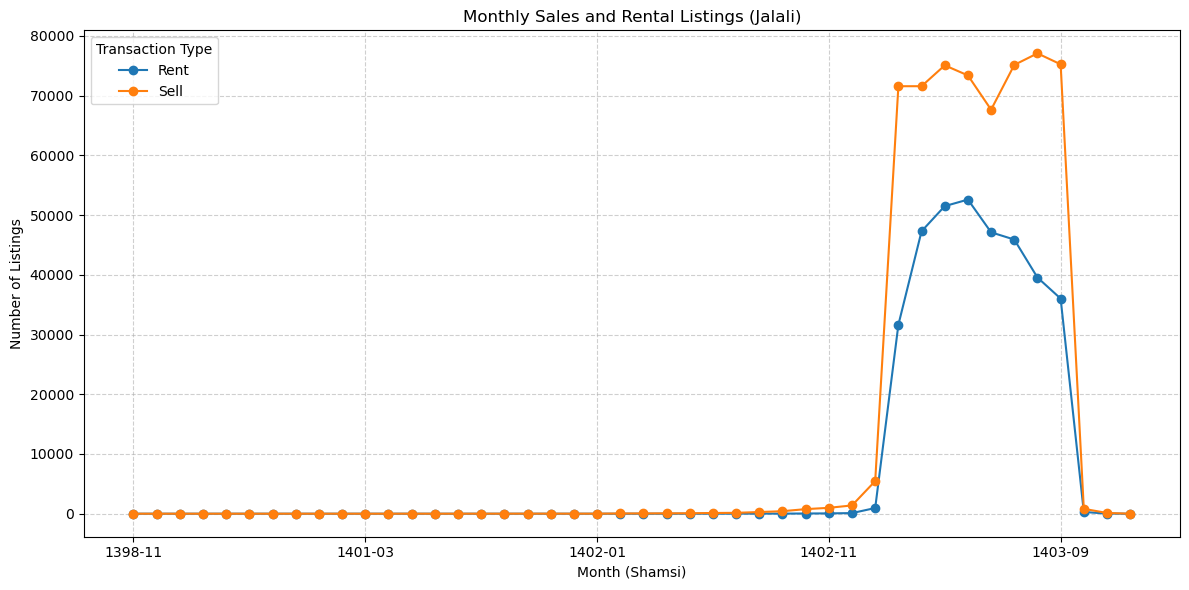

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import jdatetime

df = pd.read_csv("Divar.csv", low_memory=False)

#  فیلتر کردن داده‌ها
df_filtered = df[
    df["cat2_slug"].isin(
        [
            "residential-sell",
            "residential-rent",
            "commercial-rent",
            "commercial-sell",
        ]
    )
].copy()

#  ایجاد ستون نوع معامله
df_filtered["transaction_type"] = df_filtered["cat2_slug"].map(
    {
        "residential-sell": "Sell",
        "commercial-sell": "Sell",
        "residential-rent": "Rent",
        "commercial-rent": "Rent",
    }
)

#  تبدیل تاریخ میلادی به ماه شمسی
df_filtered["created_at_month"] = pd.to_datetime(
    df_filtered["created_at_month"]
)

df_filtered["created_at_month_shamsi"] = df_filtered["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

# گروه‌بندی بر اساس ماه شمسی و نوع معامله
monthly_counts = (
    df_filtered.groupby(["created_at_month_shamsi", "transaction_type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

#print(monthly_counts)

#  رسم نمودار
ax = monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

ax.set_title("Monthly Sales and Rental Listings (Jalali)")
ax.set_xlabel("Month (Shamsi)")
ax.set_ylabel("Number of Listings")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(title="Transaction Type")
plt.tight_layout()
plt.show()

یک بار هم آکهی‌های اجاره و فروش مسکونی و تجاری را با هم تجمیع کردیم و نمودار هر دو را رسم کردیم

آگهی‌ها عمدتا مربوط به سال ۱۴۰۳ بودند. برای همین مجددا  نمودارها را از ابتدای سال ۱۴۰۳ رسم کردیم

cat2_slug                commercial-rent  commercial-sell  residential-rent  \
created_at_month_shamsi                                                       
1403-01                              365              312               587   
1403-02                             8444             4893             23189   
1403-03                             9615             4795             37680   
1403-04                            10089             5040             41414   
1403-05                             9857             4718             42742   
1403-06                             9209             4577             37910   
1403-07                            10223             4737             35683   
1403-08                             9581             4917             29970   
1403-09                             9027             4651             26993   

cat2_slug                residential-sell  
created_at_month_shamsi                    
1403-01                              5153 

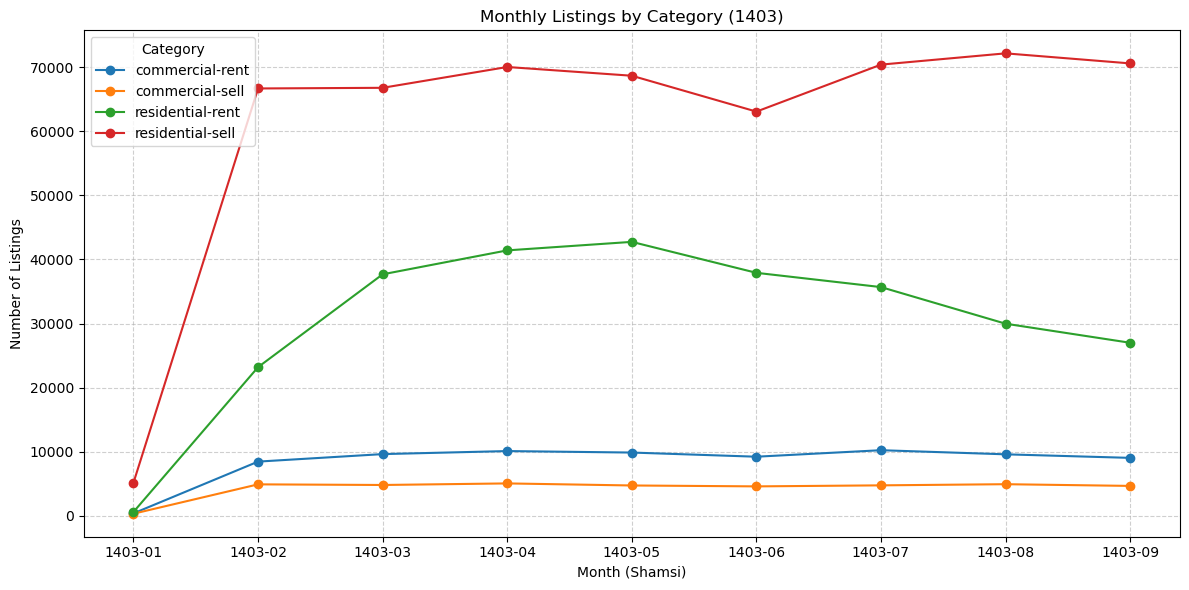

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import jdatetime

# تبدیل  تاریخ 
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

#  فیلتر کردن بازه زمانی معتبر (حذف داده‌های پرت و بسیار کمِ قبل و بعد)
df_filtered = df[
    (df["created_at_month"] >= "2024-04-01")
    & (df["created_at_month"] <= "2024-12-01")
].copy()

#  تبدیل تاریخ میلادی به ماه شمسی
df_filtered["created_at_month_shamsi"] = df_filtered["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

#  فیلتر دسته‌ها و گروه‌بندی بر اساس ماه شمسی
monthly_counts = (
    df_filtered[
        df_filtered["cat2_slug"].isin(
            [
                "residential-sell",
                "residential-rent",
                "commercial-rent",
                "commercial-sell",
            ]
        )
    ]
    .groupby(["created_at_month_shamsi", "cat2_slug"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print(monthly_counts)

#  رسم نمودار
monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Monthly Listings by Category (1403)")
plt.xlabel("Month (Shamsi)")
plt.ylabel("Number of Listings")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Category")
plt.tight_layout()

plt.show()

transaction_type          Rent   Sell
created_at_month_shamsi              
1403-01                    952   5465
1403-02                  31633  71581
1403-03                  47295  71584
1403-04                  51503  75079
1403-05                  52599  73392
1403-06                  47119  67652
1403-07                  45906  75146
1403-08                  39551  77085
1403-09                  36020  75250


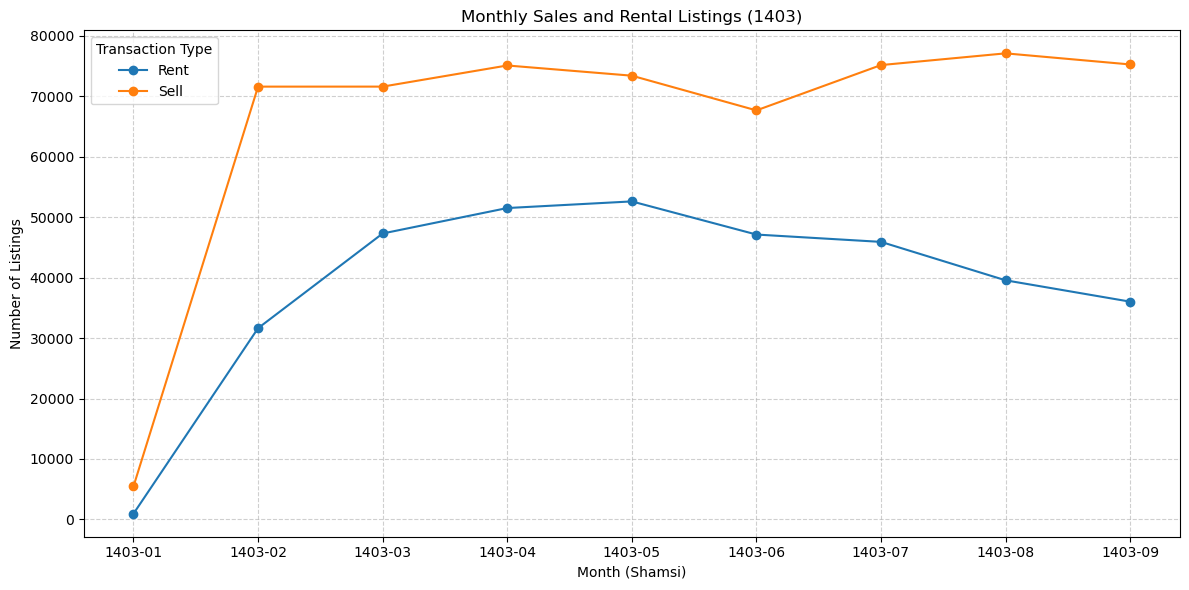

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import jdatetime

# تبدیل ستون تاریخ 
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

#  فیلتر کردن بازه زمانی معتبر و دسته‌بندی‌های هدف
df_filtered = df[
    (df["created_at_month"] >= "2024-04-01")
    & (df["created_at_month"] <= "2024-12-01")
    & (
        df["cat2_slug"].isin(
            [
                "residential-sell",
                "residential-rent",
                "commercial-rent",
                "commercial-sell",
            ]
        )
    )
].copy()

#  ایجاد ستون نوع معامله (Rent / Sell)
df_filtered["transaction_type"] = df_filtered["cat2_slug"].map(
    {
        "residential-sell": "Sell",
        "commercial-sell": "Sell",
        "residential-rent": "Rent",
        "commercial-rent": "Rent",
    }
)

#  تبدیل تاریخ میلادی به ماه شمسی
df_filtered["created_at_month_shamsi"] = df_filtered["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

#  گروه‌بندی بر اساس ماه شمسی و نوع معامله
monthly_counts = (
    df_filtered.groupby(["created_at_month_shamsi", "transaction_type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print(monthly_counts)

#  رسم نمودار
ax = monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

ax.set_title("Monthly Sales and Rental Listings (1403)")
ax.set_xlabel("Month (Shamsi)")
ax.set_ylabel("Number of Listings")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(title="Transaction Type")
plt.tight_layout()

plt.show()

 نمودارها نشان می‌دهد اجاره املاک مسکونی به طور خاص از ابتدای تابستان صعود قابل‌ توجهی است و این صعودی بودن تا تابستان ادامه دارد و در پاییز روند اجاره نزولی می‌شود